# Model Example 2: Classification — Diagnosing Breast Cancer
This notebook covers the core steps for building a **classification model**, including a few topics the regression example didn't touch: imbalanced classes, dimensionality reduction, and classification-specific evaluation.

# Data Representation in Machine Learning
As before, we split the data into a **features matrix** (`X`) and a **target array** (`y`) — this time the target is a category (malignant/benign), not a continuous number.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

data = load_breast_cancer(as_frame=True)
X = data.frame.drop(columns=["target"])   # Features matrix
y = data.frame["target"]                  # Target array (0 = malignant, 1 = benign)

print("Features matrix shape:", X.shape)
print("Target array shape:", y.shape)
X.head()


Features matrix shape: (569, 30)
Target array shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Handling Imbalanced Classes
Before training, we check the class balance. Skewed classes can make a model look accurate while actually failing the minority class — worth catching early.

In [2]:
counts = y.value_counts()
print("Class counts:\n", counts)
print("\nClass proportions:\n", (counts / counts.sum()).round(3))


Class counts:
 target
1    357
0    212
Name: count, dtype: int64

Class proportions:
 target
1    0.627
0    0.373
Name: count, dtype: float64


# Dataset Division or Splitting
We hold out a test set the model never sees during training, using **stratified** splitting so both classes keep their original proportions in train and test — important when classes are imbalanced.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 455  Test size: 114


# Feature Pipelines
We scale features and feed them straight into the classifier through a single `Pipeline`, so the same preprocessing is applied consistently to train and test data.

# Model Development
We train a **Logistic Regression** classifier — a strong, interpretable baseline for binary classification problems like this one.

In [4]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Model trained.")


Model trained.


# Evaluating Classification Model Accuracy
Unlike regression, classification has its own set of metrics. Accuracy alone can be misleading on imbalanced data, so we also check precision, recall, and F1.

In [5]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 score:  {f1:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:\n", cm)


Accuracy:  0.982
Precision: 0.986
Recall:    0.986
F1 score:  0.986

Confusion matrix:
 [[41  1]
 [ 1 71]]


# Feature Selection Using Dimensionality Reduction
The dataset has 30 features, many of them correlated. **PCA** compresses them into a smaller set of components that still capture most of the variance — useful for visualization and for speeding up training.

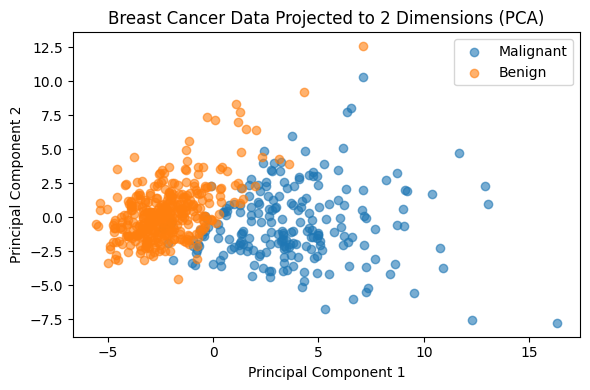

Variance explained by 2 components: 0.632


In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

plt.figure(figsize=(6, 4))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], label="Malignant", alpha=0.6)
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], label="Benign", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Breast Cancer Data Projected to 2 Dimensions (PCA)")
plt.legend()
plt.tight_layout()
plt.show()

print("Variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(3))


# Learning Curves
As with regression, a learning curve shows whether the model would improve with more training data, or whether it has plateaued.

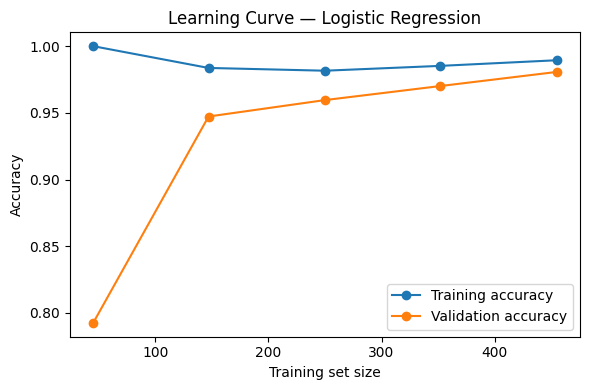

In [7]:
train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X, y, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_acc = train_scores.mean(axis=1)
val_acc = val_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_acc, "o-", label="Training accuracy")
plt.plot(train_sizes, val_acc, "o-", label="Validation accuracy")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


# Validation in Practice: Grid Search
We tune the regularization strength `C` using cross-validation, rather than picking it by hand, to find the setting that generalizes best.

In [8]:
param_grid = {"model__C": [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="f1")
grid_search.fit(X_train, y_train)

print("Best C:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_.round(3))


Best C: {'model__C': 0.1}
Best CV F1: 0.985


# Selecting the Best Model
Finally, we compare the default model against the tuned one on the untouched test set, and go with whichever performs best on the metric we care about.

In [9]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Default Logistic Regression -> F1: {:.3f}, Accuracy: {:.3f}".format(f1, acc))
print("Tuned Logistic Regression   -> F1: {:.3f}, Accuracy: {:.3f}".format(
    f1_score(y_test, y_pred_best),
    accuracy_score(y_test, y_pred_best)
))


Default Logistic Regression -> F1: 0.986, Accuracy: 0.982
Tuned Logistic Regression   -> F1: 0.979, Accuracy: 0.974
